# Analisis multivariante

## Objetivo del analisis

En este notebook se analiza de forma conjunta la relacion entre salario, empleabilidad, cualificacion academica y experiencia profesional/tecnica.

Las hipotesis trabajadas son:

- **H2.2.:** A mayor cualificacion academica, mayor empleabilidad.
- **H3.2.:** A mayor experiencia profesional y mayor experiencia tecnica, mayor salario.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append("../utils")

from funciones import *

sns.set_theme(style="whitegrid", palette="Set2")

# Cargar dataset limpio de forma robusta tanto desde el notebook como desde la raiz del repo
possible_paths = [
    Path("../data/develop_dataset_2025_limpio.csv"),
    Path("src/data/develop_dataset_2025_limpio.csv")
]

data_path = next(path for path in possible_paths if path.exists())
df = pd.read_csv(data_path, index_col=0)

df.head()

,ConvertedCompYearly,Age,EdLevel,WorkExp,YearsCode,Employment,AISelect,Industry,Country,JobSat,DevType,fue_missing_YearCode,fue_missing_WorkExp,fue_missing_Industry
8,70000.0,25-34 years old,Bachelor,9.0,15.0,Employed,Yes,Banking/Financial Services,Ukraine,8.0,Data engineer,False,False,False
33,175000.0,45-54 years old,Bachelor,24.0,26.0,Employed,No,Software Development,USA,8.0,Data engineer,False,False,False
45,80966.0,45-54 years old,Professional,20.0,23.0,Employed,No,Software Development,Hungary,8.0,AI/ML engineer,False,False,False
68,174022.0,45-54 years old,Bachelor,31.0,20.0,Freelancer,Yes,Computer Systems Design and Services,France,NaN,Data engineer,False,False,False
85,139218.0,35-44 years old,Master,15.0,20.0,Employed,Yes,Software Development,Italy,7.0,AI developer,False,False,False


In [2]:
# Variables principales
salary_col = "ConvertedCompYearly"
education_col = "EdLevel"
employment_col = "Employment"
workexp_col = "WorkExp"
yearscode_col = "YearsCode"

df_multi = df.copy()
df_multi.shape

(1741, 14)

In [3]:
# Crear variables derivadas para el analisis multivariante

experience_bins = [0, 5, 10, 15, 20, 30, 60]
experience_labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31+"]

df_multi["education_score"] = df_multi[education_col].apply(score_ed_level)
df_multi["is_employed"] = df_multi[employment_col].eq("Employed").astype(int)
df_multi["log_salary"] = np.log10(df_multi[salary_col])
df_multi["WorkExp_group"] = pd.cut(
    df_multi[workexp_col],
    bins=experience_bins,
    labels=experience_labels,
    include_lowest=True
)

df_multi[[salary_col, education_col, employment_col, workexp_col, yearscode_col, "education_score", "is_employed", "WorkExp_group"]].head()

,ConvertedCompYearly,EdLevel,Employment,WorkExp,YearsCode,education_score,is_employed,WorkExp_group
8,70000.0,Bachelor,Employed,9.0,15.0,5.0,1,6-10
33,175000.0,Bachelor,Employed,24.0,26.0,5.0,1,21-30
45,80966.0,Professional,Employed,20.0,23.0,7.0,1,16-20
68,174022.0,Bachelor,Freelancer,31.0,20.0,5.0,0,31+
85,139218.0,Master,Employed,15.0,20.0,6.0,1,11-15


## H2.2.: Cualificacion academica, empleabilidad y salario

Primero se analiza la hipotesis H2 porque en los analisis anteriores se habia tratado principalmente como relacion entre nivel educativo y empleabilidad, aunque tambien se reviso el salario como indicador adicional.

In [4]:
# Porcentaje de empleados por nivel educativo
empleados_por_educacion = (
    df_multi.groupby(education_col)["is_employed"]
    .agg(["count", "mean"])
    .assign(percentage_of_employees=lambda x: x["mean"] * 100)
    .sort_values("percentage_of_employees", ascending=False)
    .round(2)
)

empleados_por_educacion

,count,mean,percentage_of_employees
EdLevel,,,
Master,715,0.88,87.55
Bachelor,553,0.85,85.35
Professional,275,0.85,85.09
Associate,29,0.72,72.41
Some College,101,0.72,72.28
Secondary,46,0.67,67.39
Other (please specify):,13,0.54,53.85
Primary,9,0.44,44.44


In [5]:
# Salario por nivel educativo
salario_por_educacion = (
    df_multi.groupby(education_col)[salary_col]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .round(2)
)

salario_por_educacion

,count,mean,median
EdLevel,,,
Professional,275,137043.47,109438.0
Master,715,103696.19,81210.0
Bachelor,553,85987.80,69609.0
Associate,29,81884.38,61264.0
Some College,101,71717.92,54580.0
Secondary,46,168465.63,54458.5
Other (please specify):,13,50652.85,50000.0
Primary,9,19338.00,382.0


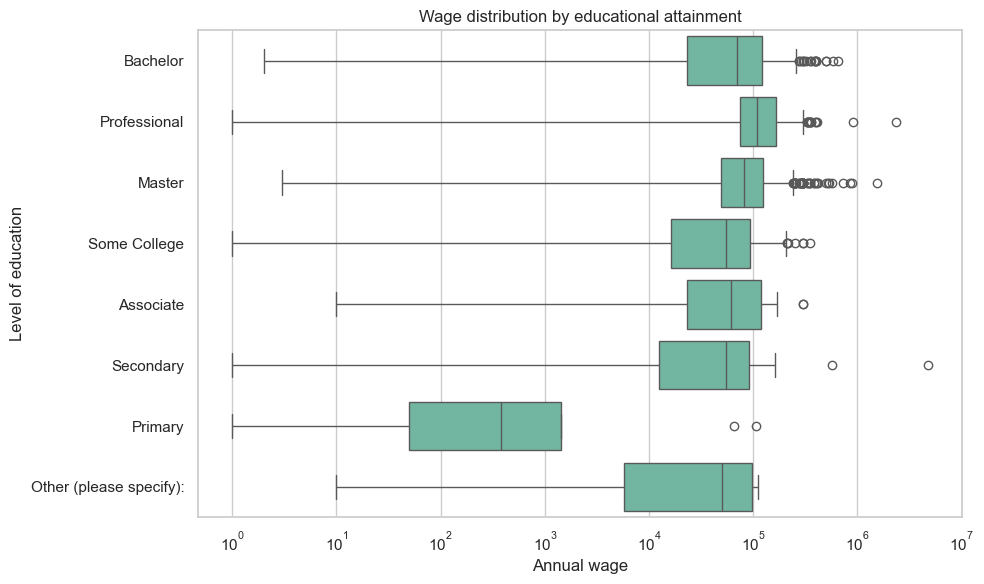

In [6]:
# Visualizar salario por nivel educativo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multi, x=salary_col, y=education_col)
plt.title("Wage distribution by educational attainment")
plt.xlabel("Annual wage")
plt.ylabel("Level of education")
plt.xscale("log")
plt.tight_layout()
plt.show()

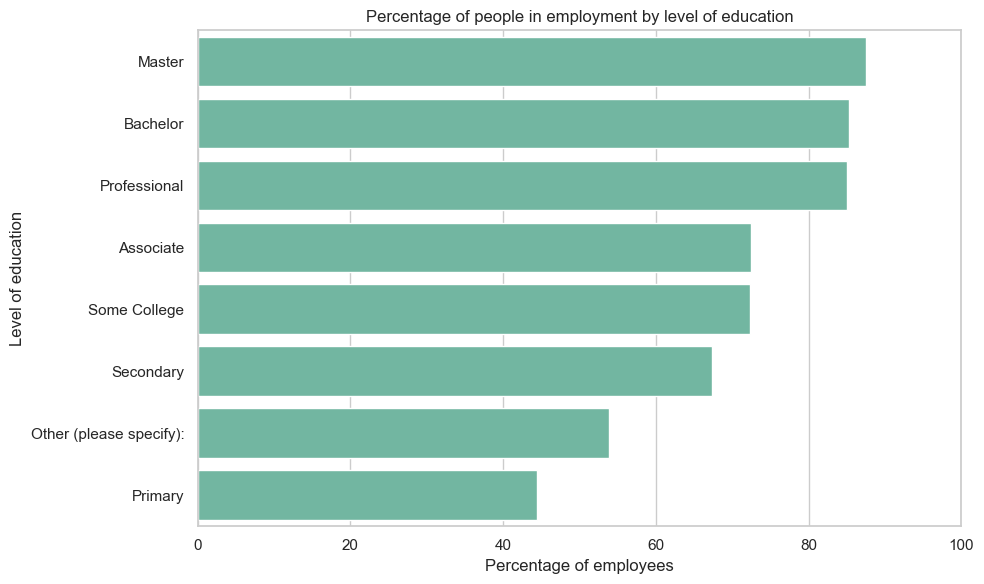

In [7]:
# Visualizar empleabilidad por nivel educativo
empleados_plot = empleados_por_educacion.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=empleados_plot, x="percentage_of_employees", y=education_col)
plt.title("Percentage of people in employment by level of education")
plt.xlabel("Percentage of employees")
plt.ylabel("Level of education")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Conclusion H2.2.

Los datos respaldan parcialmente la H2. La empleabilidad es mayor en los niveles educativos altos: master alcanza un 87.55%, grado universitario un 85.35% y titulo profesional un 85.09% de personas empleadas. En cambio, primaria se queda en un 44.44%.

El salario tambien mejora en los niveles de mayor cualificacion. La mediana salarial mas alta aparece en `Professional degree`, con 109.438 USD anuales, seguida por master y grado universitario. Por tanto, en este dataset la cualificacion academica se relaciona tanto con mayor empleabilidad como con mejores salarios, aunque el indicador principal de H2 sigue siendo la empleabilidad.

## H3.2.: Experiencia profesional, experiencia tecnica y salario

A continuacion se analiza si el salario aumenta al combinar experiencia laboral (`WorkExp`) y experiencia tecnica (`YearsCode`).

In [8]:
# Salario por rangos de experiencia laboral
salario_por_experiencia = (
    df_multi.groupby("WorkExp_group", observed=True)[salary_col]
    .agg(["count", "mean", "median"])
    .round(2)
)

salario_por_experiencia

,count,mean,median
WorkExp_group,,,
0-5,514,60748.02,46576.0
6-10,465,112515.59,84568.0
11-15,290,118249.39,95215.5
16-20,152,110968.46,90000.0
21-30,223,133777.12,116015.0
31+,97,134484.86,127616.0


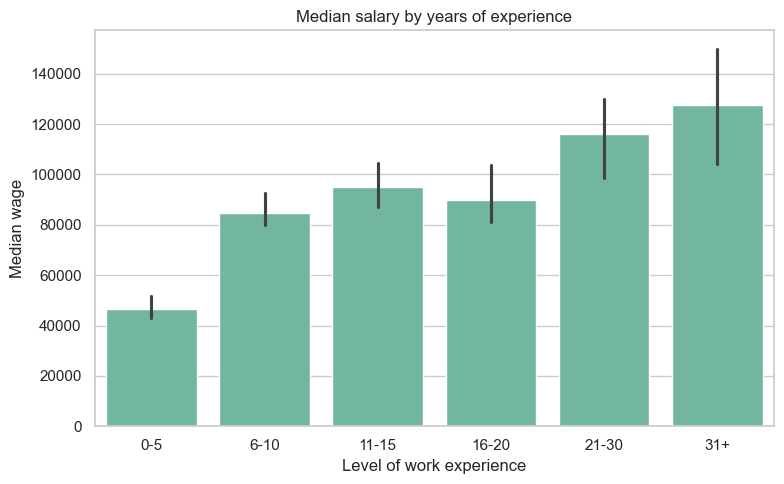

In [9]:
# Visualizar salario por rangos de experiencia laboral
plt.figure(figsize=(8, 5))
sns.barplot(data=df_multi, x="WorkExp_group", y=salary_col, estimator="median")
plt.title("Median salary by years of experience")
plt.xlabel("Level of work experience")
plt.ylabel("Median wage")
plt.tight_layout()
plt.show()

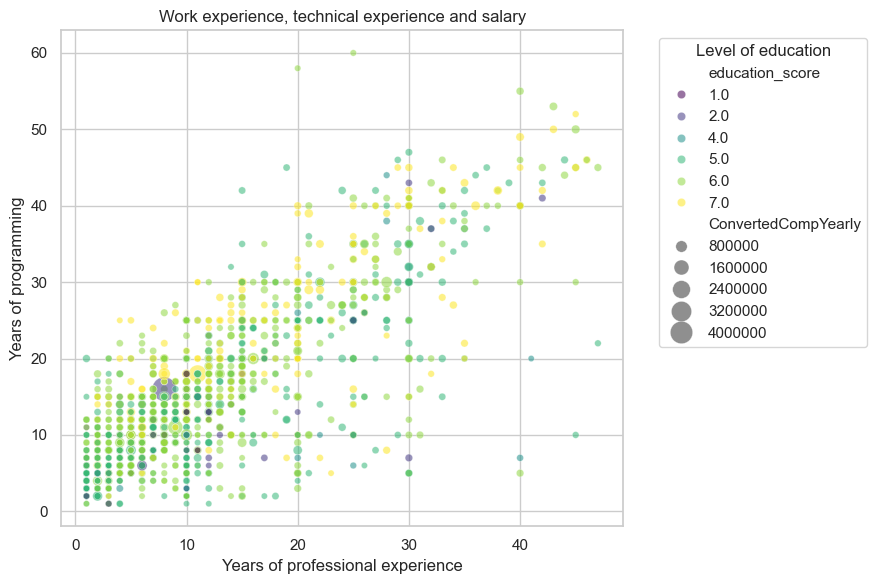

In [10]:
# Relacion conjunta entre experiencia laboral, experiencia tecnica y salario
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_multi,
    x=workexp_col,
    y=yearscode_col,
    size=salary_col,
    hue="education_score",
    sizes=(20, 300),
    alpha=0.55,
    palette="viridis"
)
plt.title("Work experience, technical experience and salary")
plt.xlabel("Years of professional experience")
plt.ylabel("Years of programming")
plt.legend(title="Level of education", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Conclusion H3.2.

La experiencia muestra una relacion positiva con el salario, especialmente al agrupar por rangos. La mediana salarial pasa de 46.576 USD en perfiles de 0-5 anos de experiencia a 127.616 USD en perfiles con 31 años o mas.

La experiencia tecnica (`YearsCode`) tambien se asocia con salarios mas altos, y en el analisis multivariante aparece como una de las variables con mayor relacion con el salario. La H3 se acepta parcialmente: la experiencia y los años programando ayudan a explicar salarios mas altos, aunque no son los unicos factores.

## Relacion conjunta: educacion + experiencia + salario

Para estudiar la relacion multivariante, se cruzan nivel educativo y experiencia laboral. Este cruce permite ver si el salario depende solo de una variable o de la combinacion entre formacion y trayectoria profesional.

In [11]:
# Mediana salarial cruzando nivel educativo y experiencia laboral
salary_edu_exp = df_multi.pivot_table(
    values=salary_col,
    index=education_col,
    columns="WorkExp_group",
    aggfunc="median",
    observed=True
).round(2)

salary_edu_exp

WorkExp_group,0-5,6-10,11-15,16-20,21-30,31+
EdLevel,,,,,,
Associate,19341.5,37623.5,120000.0,56703.5,70759.0,39005.0
Bachelor,31415.5,79231.0,94000.0,89085.5,139218.0,120000.0
Master,55687.0,87011.0,96903.0,98612.0,120000.0,123104.5
Other (please specify):,5812.0,5812.0,98612.0,71929.0,96377.0,24512.0
Primary,13.0,382.0,638.5,NaN,NaN,105353.0
Professional,78018.0,113114.5,110687.0,96377.0,117755.0,152500.0
Secondary,41765.0,47896.0,54457.0,72958.0,95999.5,135460.5
Some College,16474.0,56103.5,72243.5,75409.5,93963.0,87550.0


In [12]:
salary_edu_exp_long = (
    salary_edu_exp
    .reset_index()
    .melt(id_vars=education_col, var_name="WorkExp_group", value_name="median_salary")
    .dropna()
)

salary_edu_exp_long["Education_short"] = salary_edu_exp_long[education_col].apply(shorten_education)
salary_edu_exp_long.head()

,EdLevel,WorkExp_group,median_salary,Education_short
0,Associate,0-5,19341.5,Associate
1,Bachelor,0-5,31415.5,Bachelor
2,Master,0-5,55687.0,Master
3,Other (please specify):,0-5,5812.0,Other
4,Primary,0-5,13.0,Primary


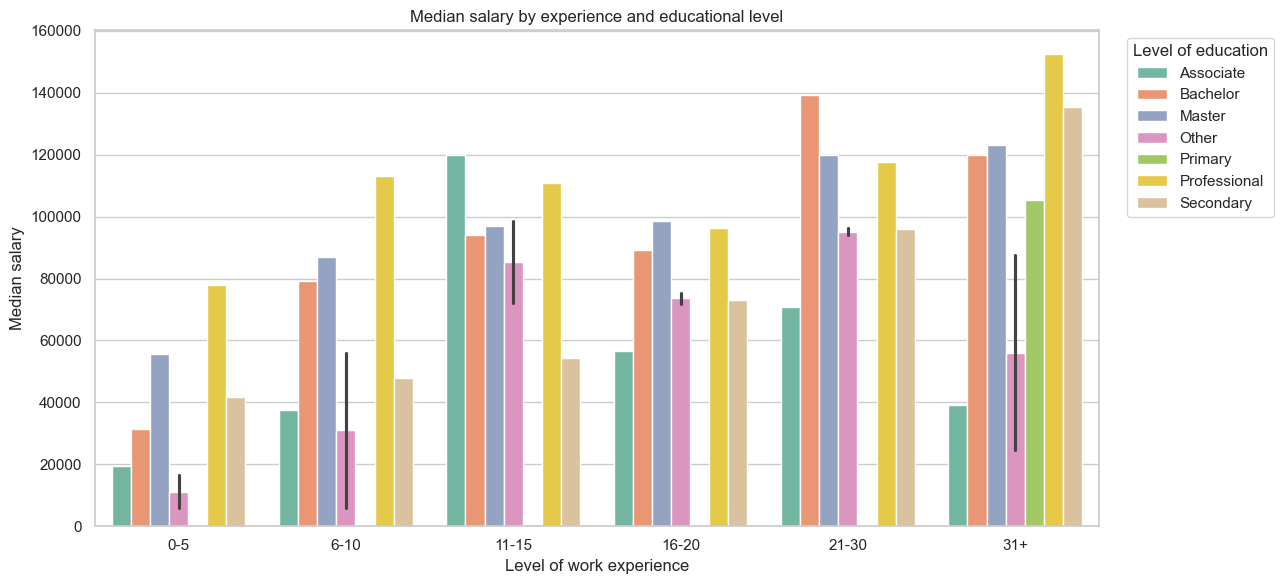

In [14]:
# Grafico alternativo: barras agrupadas de salario por experiencia y nivel educativo
plt.figure(figsize=(13, 6))
sns.barplot(
    data=salary_edu_exp_long,
    x="WorkExp_group",
    y="median_salary",
    hue="Education_short"
)
plt.title("Median salary by experience and educational level")
plt.xlabel("Level of work experience")
plt.ylabel("Median salary")
plt.legend(title="Level of education", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

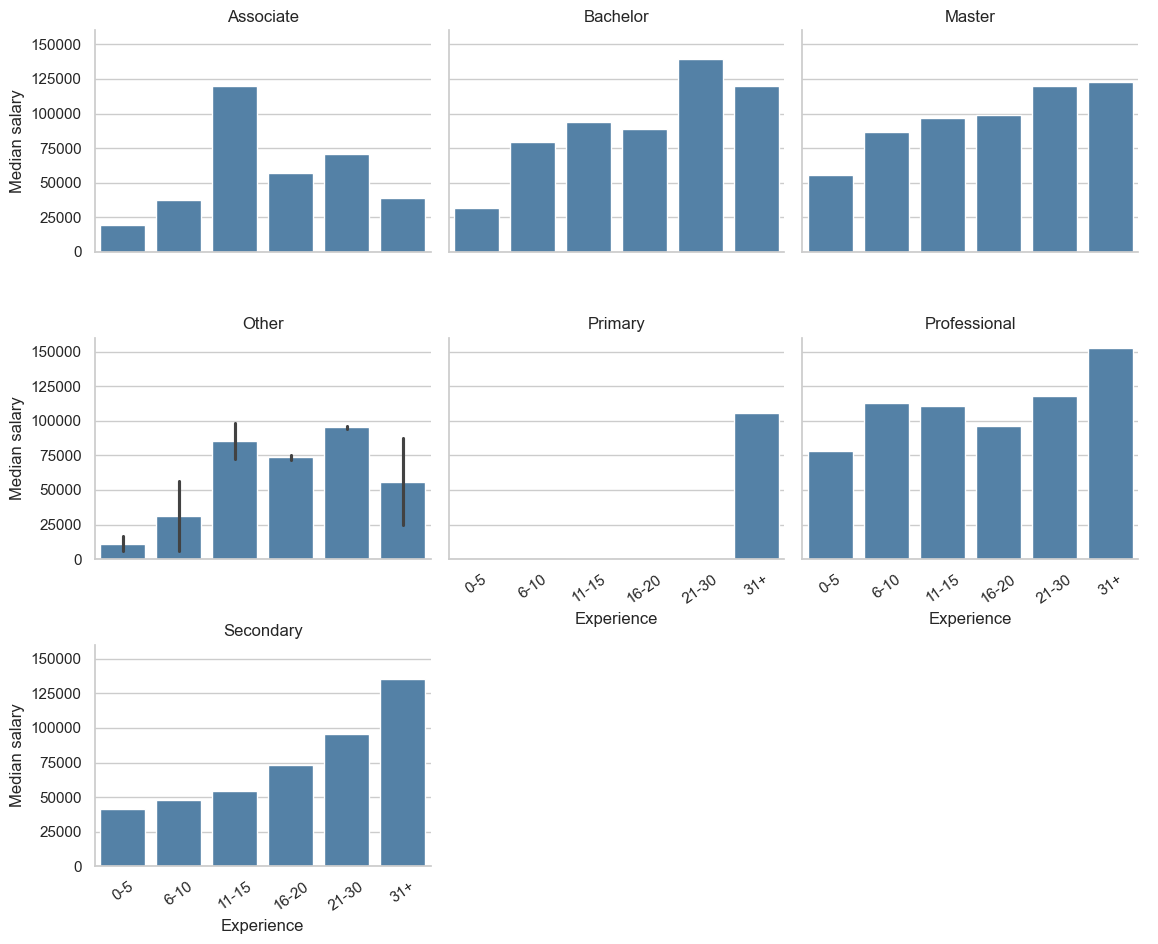

In [15]:
# Vista complementaria: facetado por nivel educativo para evitar solapamientos
salary_facet = sns.catplot(
    data=salary_edu_exp_long,
    x="WorkExp_group",
    y="median_salary",
    col="Education_short",
    col_wrap=3,
    kind="bar",
    height=3.2,
    aspect=1.2,
    sharey=True,
    color="steelblue"
)
salary_facet.set_titles("{col_name}")
salary_facet.set_axis_labels("Experience", "Median salary")
for ax in salary_facet.axes.flat:
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [16]:
# Empleabilidad cruzando nivel educativo y experiencia laboral
employment_edu_exp = df_multi.pivot_table(
    values="is_employed",
    index=education_col,
    columns="WorkExp_group",
    aggfunc="mean",
    observed=True
).mul(100).round(2)

employment_edu_exp

WorkExp_group,0-5,6-10,11-15,16-20,21-30,31+
EdLevel,,,,,,
Associate,25.00,100.00,100.00,100.00,78.57,0.00
Bachelor,86.45,88.57,88.73,80.56,85.07,56.00
Master,92.54,89.62,85.61,84.62,84.81,57.69
Other (please specify):,100.00,66.67,0.00,100.00,100.00,0.00
Primary,0.00,60.00,50.00,NaN,NaN,0.00
Professional,86.96,90.28,98.21,78.79,66.67,76.92
Secondary,73.33,54.55,66.67,66.67,100.00,0.00
Some College,59.38,80.00,85.71,90.00,75.00,61.54


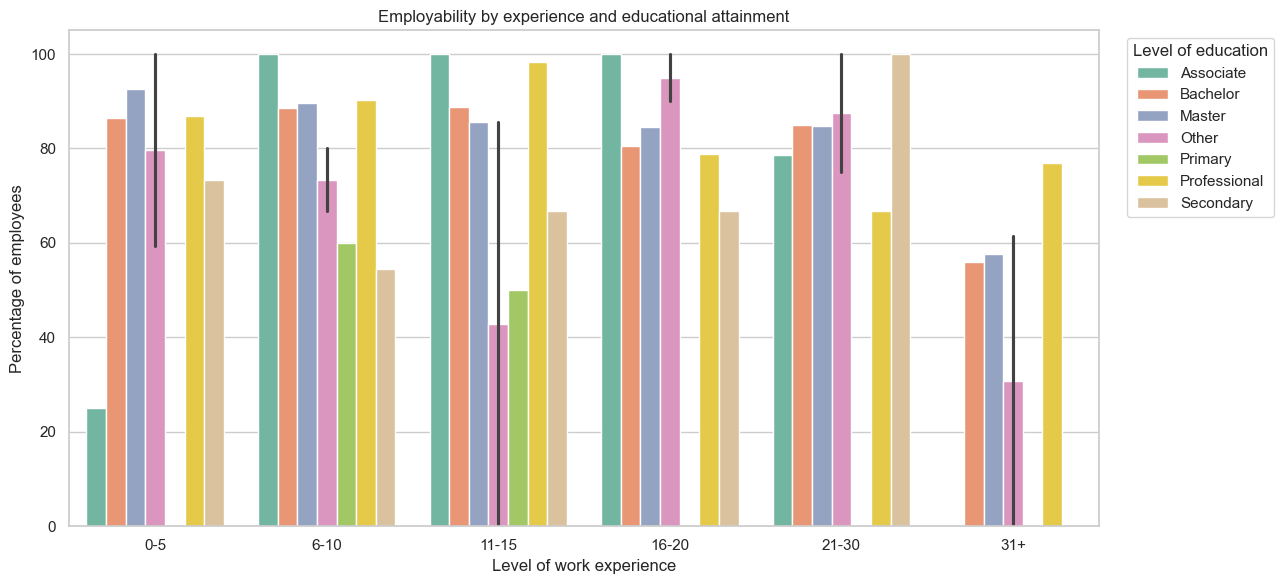

In [17]:
# Grafico alternativo: barras agrupadas de empleabilidad por experiencia y nivel educativo
employment_edu_exp_long = (
    employment_edu_exp
    .reset_index()
    .melt(id_vars=education_col, var_name="WorkExp_group", value_name="employment_pct")
    .dropna()
)

employment_edu_exp_long["Education_short"] = employment_edu_exp_long[education_col].apply(shorten_education)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=employment_edu_exp_long,
    x="WorkExp_group",
    y="employment_pct",
    hue="Education_short"
)
plt.title("Employability by experience and educational attainment")
plt.xlabel("Level of work experience")
plt.ylabel("Percentage of employees")
plt.ylim(0, 105)
plt.legend(title="Level of education", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

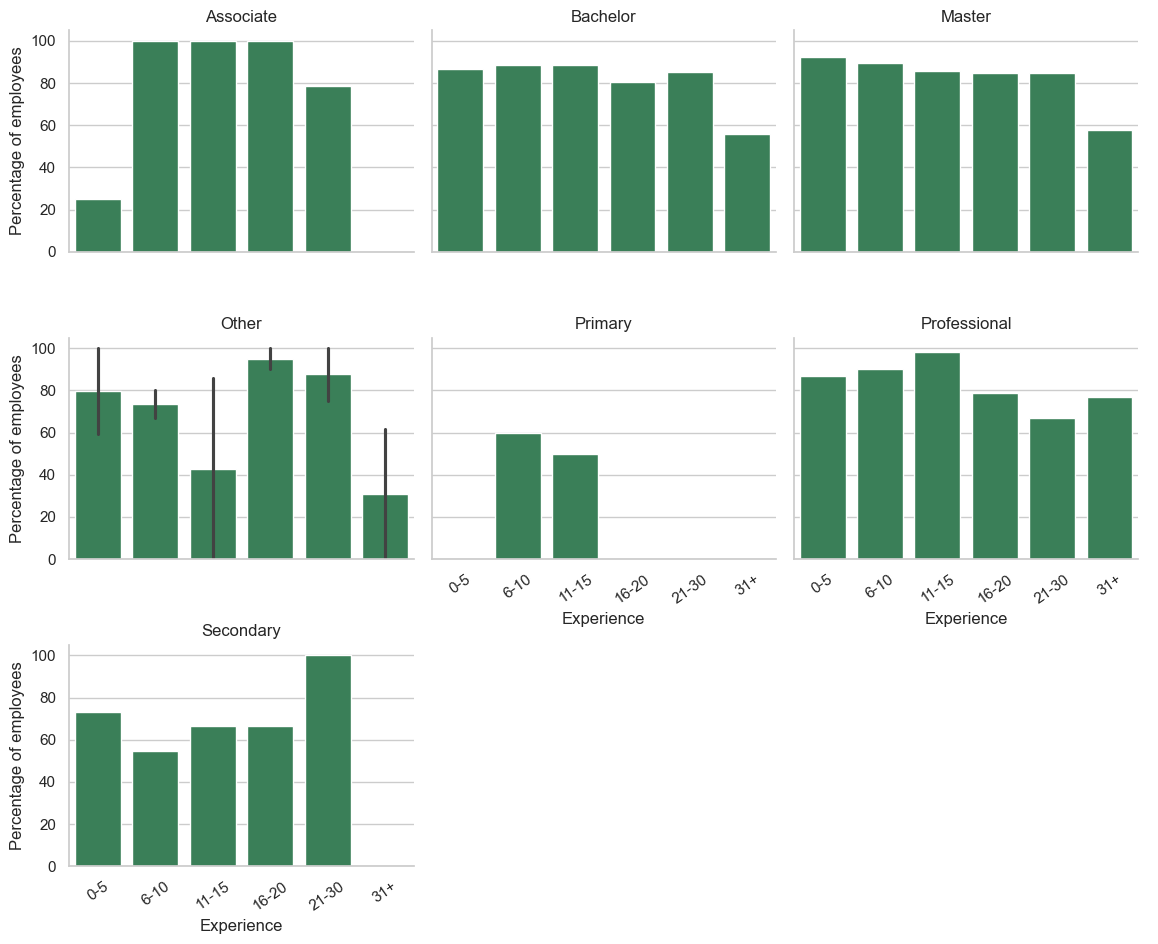

In [18]:
# Vista complementaria: empleabilidad facetada por nivel educativo
employment_facet = sns.catplot(
    data=employment_edu_exp_long,
    x="WorkExp_group",
    y="employment_pct",
    col="Education_short",
    col_wrap=3,
    kind="bar",
    height=3.2,
    aspect=1.2,
    sharey=True,
    color="seagreen"
)
employment_facet.set_titles("{col_name}")
employment_facet.set_axis_labels("Experience", "Percentage of employees")
for ax in employment_facet.axes.flat:
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Interpretacion conjunta

El cruce entre educacion y experiencia muestra que el salario no depende de una sola variable. Los niveles educativos altos suelen presentar mejores medianas, pero la experiencia laboral tambien desplaza el salario hacia arriba dentro de varios niveles academicos.

En empleabilidad, los niveles de master, grado universitario y titulo profesional mantienen porcentajes altos, aunque los grupos con mucha experiencia pueden incluir perfiles retirados, autonomos o no empleados, lo que reduce el porcentaje de `Employed` en algunos tramos.

## Correlaciones entre variables principales

Se usa `log_salary` para reducir el efecto de los salarios extremos. Esto permite interpretar mejor la relacion entre salario, experiencia, educacion y empleabilidad.

In [19]:
corr_vars = ["log_salary", workexp_col, yearscode_col, "education_score", "is_employed"]
corr_matrix = df_multi[corr_vars].corr(numeric_only=True).round(3)

corr_matrix

,log_salary,WorkExp,YearsCode,education_score,is_employed
log_salary,1.000,0.221,0.316,0.248,0.162
WorkExp,0.221,1.000,0.778,0.072,-0.159
YearsCode,0.316,0.778,1.000,0.175,-0.055
education_score,0.248,0.072,0.175,1.000,0.098
is_employed,0.162,-0.159,-0.055,0.098,1.000


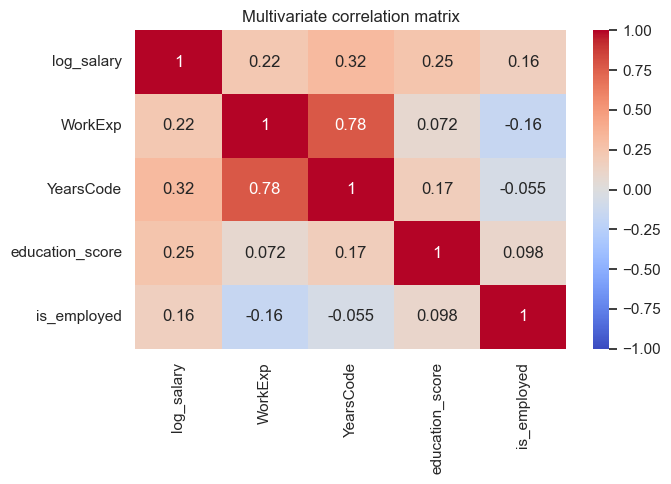

In [20]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Multivariate correlation matrix")
plt.tight_layout()
plt.show()

### Interpretacion de correlaciones

La relacion mas clara con el salario logaritmico aparece en `YearsCode` (0.316), seguida por `education_score` (0.248) y `WorkExp` (0.221). La variable `is_employed` tambien se relaciona positivamente con el salario logaritmico (0.162), aunque de forma mas moderada.

Esto refuerza la idea de que el salario se explica mejor combinando experiencia tecnica, experiencia laboral, educacion y situacion laboral.

## Modelo multivariante para salario

Se construye un modelo lineal sencillo con variables estandarizadas. El objetivo no es predecir perfectamente el salario, sino comparar que variables tienen mayor peso relativo al analizarse juntas.

In [21]:
# Modelo lineal sencillo para salario logaritmico
model_salary = df_multi[["log_salary", workexp_col, yearscode_col, "education_score", "is_employed"]].dropna()

y = model_salary["log_salary"].values
X = model_salary[[workexp_col, yearscode_col, "education_score", "is_employed"]].copy()

# Estandarizar variables para comparar coeficientes
X_std = (X - X.mean()) / X.std(ddof=0)
X_matrix = np.column_stack([np.ones(len(X_std)), X_std.values])

coef = np.linalg.lstsq(X_matrix, y, rcond=None)[0]
pred = X_matrix @ coef
r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()

coef_salary = pd.DataFrame({
    "variable": ["intercept"] + list(X.columns),
    "coeficiente": coef
}).round(4)

print(f"Model R2: {r2:.3f}")
print(f"Records used: {len(model_salary)}")
coef_salary

Model R2: 0.146
Records used: 1627


,variable,coeficiente
0,intercept,4.7440
1,WorkExp,0.0249
2,YearsCode,0.1787
3,education_score,0.1332
4,is_employed,0.0833


### Conclusion del modelo de salario

El modelo explica aproximadamente un 14,6% de la variabilidad del salario logaritmico. No es un modelo predictivo fuerte, pero sirve para comparar efectos relativos.

Al analizar las variables conjuntamente, `YearsCode` mantiene el mayor peso positivo (0.1787), seguido por `education_score` (0.1332) e `is_employed` (0.0833). `WorkExp` tambien es positivo, pero su peso baja (0.0249) cuando se controla por anos programando y educacion.

Esto sugiere que la experiencia tecnica y la cualificacion academica ayudan a explicar el salario, mientras que la experiencia laboral general aporta informacion adicional pero parcialmente solapada con `YearsCode`.

## Modelo multivariante para empleabilidad

Para H2 se analiza tambien la empleabilidad como variable objetivo. Se usa un modelo lineal sencillo sobre `is_employed`, interpretado solo de forma exploratoria.

In [22]:
# Modelo exploratorio para empleabilidad
model_employment = df_multi[["is_employed", workexp_col, yearscode_col, "education_score"]].dropna()

y_emp = model_employment["is_employed"].values
X_emp = model_employment[[workexp_col, yearscode_col, "education_score"]].copy()

X_emp_std = (X_emp - X_emp.mean()) / X_emp.std(ddof=0)
X_emp_matrix = np.column_stack([np.ones(len(X_emp_std)), X_emp_std.values])

coef_emp = np.linalg.lstsq(X_emp_matrix, y_emp, rcond=None)[0]
pred_emp = X_emp_matrix @ coef_emp
r2_emp = 1 - ((y_emp - pred_emp) ** 2).sum() / ((y_emp - y_emp.mean()) ** 2).sum()

coef_employment = pd.DataFrame({
    "variable": ["intercept"] + list(X_emp.columns),
    "coeficiente": coef_emp
}).round(4)

print(f"Model R2: {r2_emp:.3f}")
print(f"Records used: {len(model_employment)}")
coef_employment

Model R2: 0.046
Records used: 1627


,variable,coeficiente
0,intercept,0.8531
1,WorkExp,-0.0965
2,YearsCode,0.0440
3,education_score,0.0340


### Conclusion del modelo de empleabilidad

El modelo de empleabilidad tiene una capacidad explicativa baja, con un R2 aproximado de 4,6%. Esto indica que la situacion laboral no se explica completamente solo con educacion y experiencia.

Aun asi, `education_score` mantiene una relacion positiva con estar empleado (0.0340
), lo que refuerza parcialmente la H2. `YearsCode` tambien aparece con efecto positivo (0.0440). En cambio, `WorkExp` aparece con coeficiente negativo (-0.0965), probablemente porque los tramos de mayor experiencia incluyen mas perfiles retirados, autonomos o no clasificados como `Employed`.

Por tanto, la educacion se relaciona con la empleabilidad, pero no basta para explicarla por completo.

## Conclusion final del analisis multivariante

El analisis multivariante muestra que salario, empleabilidad, cualificacion academica y experiencia estan relacionados, pero no de forma aislada.

La H2 se acepta parcialmente porque los niveles educativos mas altos presentan mayores porcentajes de personas empleadas y mejores medianas salariales. Sin embargo, la empleabilidad tambien depende de otros factores no incluidos directamente en estas hipotesis, como pais, tipo de rol, industria o situacion profesional concreta.

La H3 tambien se acepta parcialmente. La experiencia laboral y, sobre todo, la experiencia tecnica medida con `YearsCode`, se asocian con salarios mas altos. Aun asi, la dispersion salarial sigue siendo elevada, por lo que la experiencia no explica por si sola las diferencias de salario.

En conjunto, el salario parece estar mas relacionado con la combinacion de experiencia tecnica, cualificacion academica, experiencia laboral y situacion laboral. La empleabilidad, por su parte, mejora con la cualificacion academica, aunque el modelo muestra que hay otros factores relevantes que tambien deberian considerarse.